In [1]:
import utils
import numpy as np
import pandas as pd
import os
from scipy.stats import chisquare

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme
sns.set_theme()

pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)

In [2]:
# Make output folders
WSLS_output_dir = os.path.join('..','..','plots','behavioural','behavioural_modelling','WSLS')
if not os.path.exists(WSLS_output_dir):
    os.makedirs(WSLS_output_dir)
CSIS_output_dir = os.path.join('..','..','plots','behavioural','behavioural_modelling','CSIS')
if not os.path.exists(CSIS_output_dir):
    os.makedirs(CSIS_output_dir)

In [3]:
# Preparation
experiment_output_path = os.path.join('..', '..', '..', 'phd_1_task', 'experiment_output', 'behavioural_files')
#experiment_output_path = os.path.join('..', '..', '..', 'phd_1_task', 'experiment_output_verena')

In [4]:
unique_subject_ids = list(range(801, 816))
unique_sessions = [1]

recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(experiment_output_path, unique_subject_ids, unique_sessions)
print(recent_results)

['../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-801_session-01_dummy_2024-09-09_15-09-26.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-802_session-01_dummy_2024-09-10_11-06-48.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-803_session-01_dummy_2024-09-10_13-40-11.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-804_session-01_dummy_2024-09-10_15-41-26.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-805_session-01_dummy_2024-09-11_09-08-32.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-806_session-01_dummy_2024-09-11_11-12-35.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-807_session-01_dummy_2024-09-11_13-42-58.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-808_session-01_dummy_2024-09-1

In [5]:
# Opens all the files and combines them into one dataframe
combined_results_dataframe = utils.analysis_functions.combine_result_files(recent_results)
if 'verena' in experiment_output_path:
    combined_dataframe = combined_results_dataframe[~combined_results_dataframe['stimuli_type'].isin([2, 4])]
    
print(combined_results_dataframe)

       trial  emotional_cue_time response objectively_correct  \
0          0        1.725887e+09      NaN                Late   
1          1        1.725887e+09     down                Even   
2          2        1.725887e+09     down                Even   
3          3        1.725887e+09       up                Even   
4          4        1.725888e+09       up                Even   
...      ...                 ...      ...                 ...   
10015    663        1.726655e+09     down                True   
10016    664        1.726655e+09     down                True   
10017    665        1.726655e+09     down                True   
10018    666        1.726655e+09       up                True   
10019    667        1.726655e+09       up                True   

      subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
0                     Late   1.725887e+09  1.201   1.725887e+09             1   
1                    False   1.725887e+09  0.394   1.7258

# WSLS
Determine how often the Win-Stay Lost-Shift strategy is used. Plot whether there is a difference between conditions.

In [6]:
# Add congruency as a column
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)

In [7]:
# Add two 'one-back' columns and a WSLS column
dataframe_WSLS = utils.learning_models.add_WSLS_column(combined_results_dataframe)
dataframe_CSIS = utils.learning_models.add_CSIS_column(dataframe_WSLS)

      subject_id     session  stimuli_type  trial  \
0        sub-801  session-01             1      0   
2011     sub-804  session-01             1     15   
9592     sub-815  session-01             1    481   
3772     sub-806  session-01             3    197   
2009     sub-804  session-01             1      9   
...          ...         ...           ...    ...   
1360     sub-803  session-01             1     50   
8345     sub-813  session-01             1    657   
8347     sub-813  session-01             1    662   
8334     sub-813  session-01             1    636   
10019    sub-815  session-01             3    665   

      subjectively_correct_one_back response_one_back response  WSLS  
0                               NaN               NaN      NaN     0  
2011                           Late               NaN       up     0  
9592                           Late               NaN     down     0  
3772                           Late               NaN       up     0  
2009    

# Check congruency, valence and volatility
### For WSLS

In [8]:
# Check a block's congruency
dataframe_WSLS['congruency'] = dataframe_WSLS.apply(utils.analysis_functions.check_congruency, axis=1)

# Check a block's valence
dataframe_WSLS['valence'] = dataframe_WSLS.apply(utils.analysis_functions.check_valence, axis=1)

# Check a block's volatility
dataframe_WSLS = dataframe_WSLS[dataframe_WSLS['probability_condition'] != 50]
dataframe_with_volatility = dataframe_WSLS.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)
dataframe_with_volatility = dataframe_with_volatility.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
dataframe_with_volatility.reset_index(drop=True, inplace=True)
print(dataframe_with_volatility[['subject_id', 'session', 'congruency', 'valence', 'volatility', 'WSLS']])

unique_valence_conditions = dataframe_with_volatility['valence'].unique()
unique_congruency_conditions = dataframe_with_volatility['congruency'].unique()
unique_volatility_conditions = dataframe_with_volatility['volatility'].unique()

dataframe_without_volatility = dataframe_WSLS

     subject_id     session congruency valence volatility  WSLS
0       sub-801  session-01  congruent   angry     stable     2
1       sub-801  session-01  congruent   angry     stable     1
2       sub-801  session-01  congruent   angry     stable     3
3       sub-801  session-01  congruent   angry     stable     4
4       sub-801  session-01  congruent   angry     stable     2
...         ...         ...        ...     ...        ...   ...
9895    sub-815  session-01  congruent   happy   volatile     0
9896    sub-815  session-01  congruent   happy   volatile     4
9897    sub-815  session-01  congruent   happy   volatile     2
9898    sub-815  session-01  congruent   happy   volatile     2
9899    sub-815  session-01  congruent   happy   volatile     4

[9900 rows x 6 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5038/1825596363.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataframe_with_volatility = dataframe_WSLS.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)


# Plot the WSLS separately for staying and shifting
- Valence
- Volatility
- Congruency
- Valence/Volatility
- Congruency/Volatility

In [9]:
# First combine two columns
grouping_factor = 'valence'
dataframe_valence_volatility = dataframe_with_volatility

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

   subject_id     session valence  p_win_stay  p_lose_stay
0     sub-801  session-01   angry    0.717241     0.701149
1     sub-801  session-01   happy    0.812903     0.803681
2     sub-802  session-01   angry    0.786408     0.452174
3     sub-802  session-01   happy    0.763285     0.487179
4     sub-803  session-01   angry    0.908676     0.550000
5     sub-803  session-01   happy    0.919643     0.565657
6     sub-804  session-01   angry    0.729592     0.362069
7     sub-804  session-01   happy    0.788889     0.244604
8     sub-805  session-01   angry    0.836449     0.288288
9     sub-805  session-01   happy    0.886700     0.292683
10    sub-806  session-01   angry    0.894515     0.516484
11    sub-806  session-01   happy    0.875000     0.340426
12    sub-807  session-01   angry    0.470968     0.315385
13    sub-807  session-01   happy    0.543353     0.265152
14    sub-808  session-01   angry    0.790816     0.375000
15    sub-808  session-01   happy    0.779570     0.4233

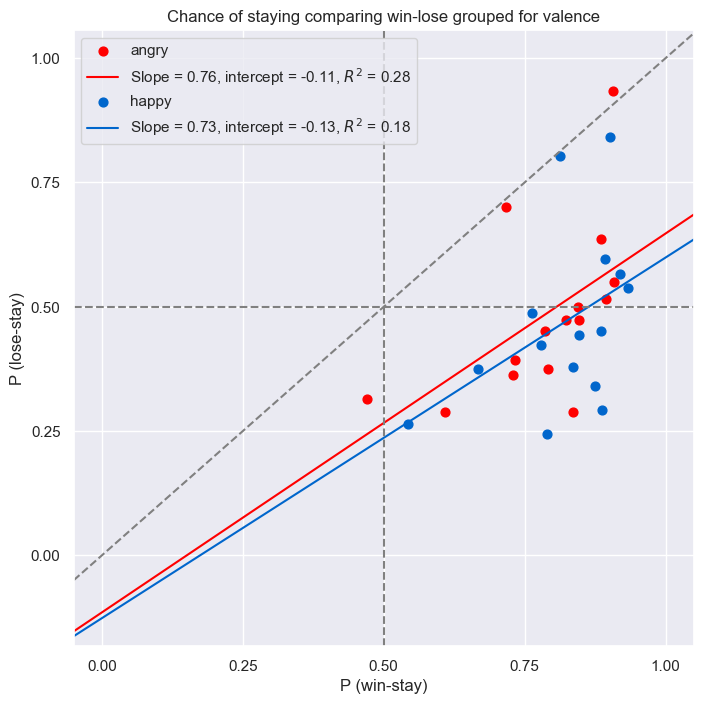

In [10]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(8, 8))
scatterplot_colours = ['#FF0000', '#0066CC']

for index, value in enumerate(unique_valence_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)

    # Extract x and y values
    x = filtered_dataframe['p_win_stay']
    y = filtered_dataframe['p_lose_stay']
    
    # Fit a regression line using numpy's polyfit (degree 1 for linear regression)
    slope, intercept = np.polyfit(x, y, 1)

    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0, 1]
    r_squared = correlation_xy**2
    
    # Plot the regression line
    ax.axline((0, intercept), slope=slope, color=scatterplot_colours[index], label=f'Slope = {slope:.2f}, intercept = {intercept:.2f}, $R^2$ = {r_squared:.2f}')

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing win-lose grouped for {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(WSLS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [11]:
# First combine two columns
grouping_factor = 'volatility'
dataframe_valence_volatility = dataframe_with_volatility

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

   subject_id     session volatility  p_win_stay  p_lose_stay
0     sub-801  session-01     stable    0.825806     0.778894
1     sub-801  session-01   volatile    0.703448     0.710145
2     sub-802  session-01     stable    0.740566     0.483607
3     sub-802  session-01   volatile    0.810945     0.454545
4     sub-803  session-01     stable    0.914729     0.540000
5     sub-803  session-01   volatile    0.913514     0.575758
6     sub-804  session-01     stable    0.796875     0.338235
7     sub-804  session-01   volatile    0.717391     0.252101
8     sub-805  session-01     stable    0.863636     0.289062
9     sub-805  session-01   volatile    0.857143     0.292453
10    sub-806  session-01     stable    0.898551     0.482353
11    sub-806  session-01   volatile    0.865285     0.380000
12    sub-807  session-01     stable    0.535912     0.291339
13    sub-807  session-01   volatile    0.476190     0.288889
14    sub-808  session-01     stable    0.799020     0.383459
15    su

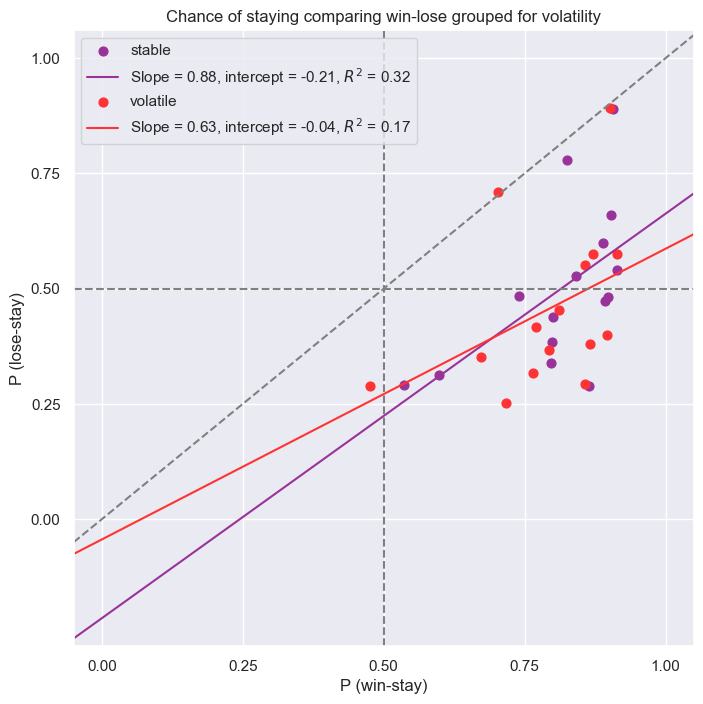

In [12]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(8, 8))
scatterplot_colours = ['#993399', '#FF3333']

for index, value in enumerate(unique_volatility_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)

    # Extract x and y values
    x = filtered_dataframe['p_win_stay']
    y = filtered_dataframe['p_lose_stay']

    # Fit a regression line using numpy's polyfit (degree 1 for linear regression)
    slope, intercept = np.polyfit(x, y, 1)

    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0, 1]
    r_squared = correlation_xy**2

    # Plot the regression line
    ax.axline((0, intercept), slope=slope, color=scatterplot_colours[index], label=f'Slope = {slope:.2f}, intercept = {intercept:.2f}, $R^2$ = {r_squared:.2f}')

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing win-lose grouped for {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(WSLS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [13]:
# First combine two columns
grouping_factor = 'congruency'
dataframe_valence_volatility = dataframe_with_volatility

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

   subject_id     session   congruency  p_win_stay  p_lose_stay
0     sub-801  session-01    congruent    0.814634     0.589474
1     sub-801  session-01  incongruent    0.663158     0.814050
2     sub-802  session-01    congruent    0.854167     0.575472
3     sub-802  session-01  incongruent    0.664740     0.380952
4     sub-803  session-01    congruent    0.905830     0.536082
5     sub-803  session-01  incongruent    0.922727     0.578431
6     sub-804  session-01    congruent    0.813725     0.256881
7     sub-804  session-01  incongruent    0.691860     0.328767
8     sub-805  session-01    congruent    0.902954     0.315315
9     sub-805  session-01  incongruent    0.805556     0.268293
10    sub-806  session-01    congruent    0.928270     0.430108
11    sub-806  session-01  incongruent    0.840517     0.423913
12    sub-807  session-01    congruent    0.554217     0.282609
13    sub-807  session-01  incongruent    0.462963     0.298387
14    sub-808  session-01    congruent  

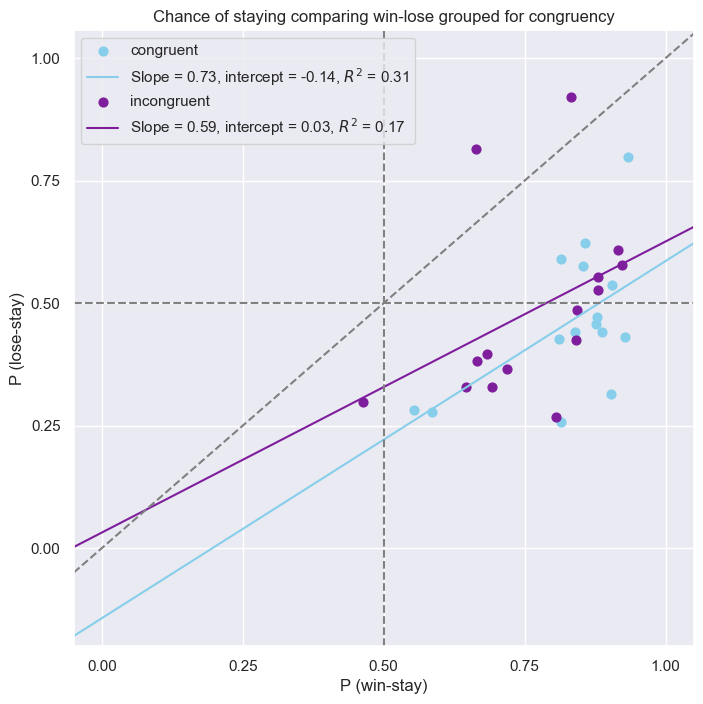

In [14]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(8, 8))
scatterplot_colours = ['#87CEEB', '#7E1E9C']

for index, value in enumerate(unique_congruency_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)

    # Extract x and y values
    x = filtered_dataframe['p_win_stay']
    y = filtered_dataframe['p_lose_stay']

    # Fit a regression line using numpy's polyfit (degree 1 for linear regression)
    slope, intercept = np.polyfit(x, y, 1)

    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0, 1]
    r_squared = correlation_xy**2

    # Plot the regression line
    ax.axline((0, intercept), slope=slope, color=scatterplot_colours[index], label=f'Slope = {slope:.2f}, intercept = {intercept:.2f}, $R^2$ = {r_squared:.2f}')

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing win-lose grouped for {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(WSLS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [15]:
# First combine two columns
grouping_factor_1 = 'valence'
grouping_factor_2 = 'volatility'
grouping_factor = f'{grouping_factor_1}_{grouping_factor_2}'
dataframe_valence_volatility = dataframe_with_volatility
dataframe_valence_volatility[grouping_factor] = dataframe_valence_volatility[grouping_factor_1] + ' & ' + dataframe_valence_volatility[grouping_factor_2]

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

   subject_id     session valence_volatility  p_win_stay  p_lose_stay
0     sub-801  session-01     angry & stable    0.792208     0.760000
1     sub-801  session-01   angry & volatile    0.632353     0.621622
2     sub-801  session-01     happy & stable    0.858974     0.797980
3     sub-801  session-01   happy & volatile    0.766234     0.812500
4     sub-802  session-01     angry & stable    0.728972     0.448276
5     sub-802  session-01   angry & volatile    0.848485     0.456140
6     sub-802  session-01     happy & stable    0.752381     0.515625
7     sub-802  session-01   happy & volatile    0.774510     0.452830
8     sub-803  session-01     angry & stable    0.896825     0.519231
9     sub-803  session-01   angry & volatile    0.924731     0.583333
10    sub-803  session-01     happy & stable    0.931818     0.562500
11    sub-803  session-01   happy & volatile    0.902174     0.568627
12    sub-804  session-01     angry & stable    0.752577     0.415385
13    sub-804  sessi

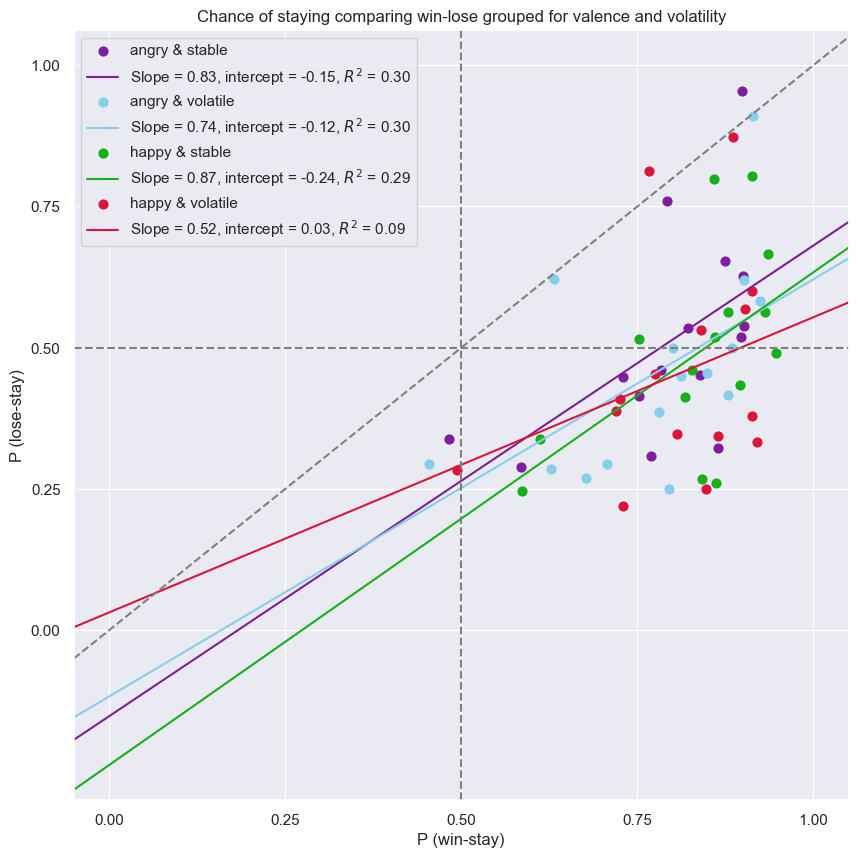

In [16]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(10, 10))
scatterplot_colours = ['#7E1E9C', '#87CEEB', '#15B01A', '#DC143C']
unique_conditions = WSLS_dataframe_averages['valence_volatility'].unique()

for index, value in enumerate(unique_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)

    # Extract x and y values
    x = filtered_dataframe['p_win_stay']
    y = filtered_dataframe['p_lose_stay']

    # Fit a regression line using numpy's polyfit (degree 1 for linear regression)
    slope, intercept = np.polyfit(x, y, 1)

    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0, 1]
    r_squared = correlation_xy**2

    # Plot the regression line
    ax.axline((0, intercept), slope=slope, color=scatterplot_colours[index], label=f'Slope = {slope:.2f}, intercept = {intercept:.2f}, $R^2$ = {r_squared:.2f}')

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing win-lose grouped for {grouping_factor_1} and {grouping_factor_2}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(WSLS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [17]:
# First combine two columns
grouping_factor_1 = 'congruency'
grouping_factor_2 = 'volatility'
grouping_factor = f'{grouping_factor_1}_{grouping_factor_2}'
dataframe_valence_volatility = dataframe_with_volatility
dataframe_valence_volatility[grouping_factor] = dataframe_valence_volatility[grouping_factor_1] + ' & ' + dataframe_valence_volatility[grouping_factor_2]

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

   subject_id     session   congruency_volatility  p_win_stay  p_lose_stay
0     sub-801  session-01      congruent & stable    0.848739     0.615385
1     sub-801  session-01    congruent & volatile    0.767442     0.558140
2     sub-801  session-01    incongruent & stable    0.750000     0.836735
3     sub-801  session-01  incongruent & volatile    0.610169     0.778947
4     sub-802  session-01      congruent & stable    0.844828     0.591837
5     sub-802  session-01    congruent & volatile    0.862903     0.561404
6     sub-802  session-01    incongruent & stable    0.614583     0.410959
7     sub-802  session-01  incongruent & volatile    0.727273     0.339623
8     sub-803  session-01      congruent & stable    0.896825     0.528302
9     sub-803  session-01    congruent & volatile    0.917526     0.545455
10    sub-803  session-01    incongruent & stable    0.931818     0.553191
11    sub-803  session-01  incongruent & volatile    0.909091     0.600000
12    sub-804  session-01

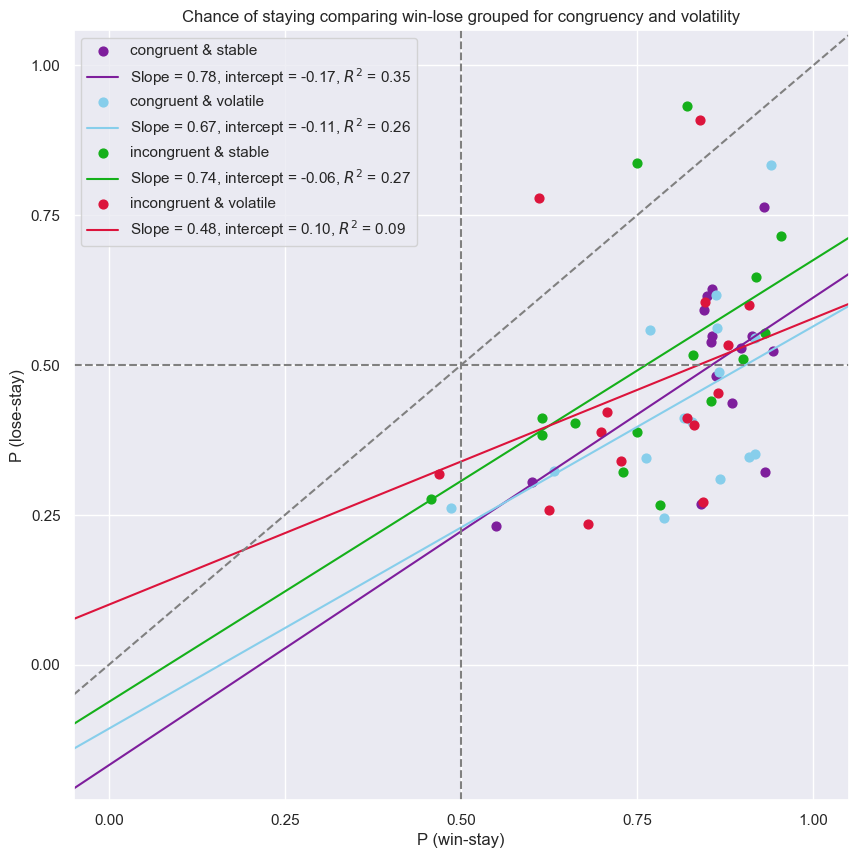

In [18]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(10, 10))
scatterplot_colours = ['#7E1E9C', '#87CEEB', '#15B01A', '#DC143C']
unique_conditions = WSLS_dataframe_averages['congruency_volatility'].unique()

for index, value in enumerate(unique_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)

    # Extract x and y values
    x = filtered_dataframe['p_win_stay']
    y = filtered_dataframe['p_lose_stay']

    # Fit a regression line using numpy's polyfit (degree 1 for linear regression)
    slope, intercept = np.polyfit(x, y, 1)

    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0, 1]
    r_squared = correlation_xy**2

    # Plot the regression line
    ax.axline((0, intercept), slope=slope, color=scatterplot_colours[index], label=f'Slope = {slope:.2f}, intercept = {intercept:.2f}, $R^2$ = {r_squared:.2f}')

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing win-lose grouped for {grouping_factor_1} and {grouping_factor_2}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(WSLS_output_dir, f'{plot_name}.pdf'))
plt.show()

# Check congruency, valence and volatility
### For CSIS (congruent-stay/incongruent-switch)

In [19]:
# Check a block's congruency
dataframe_CSIS['congruency'] = dataframe_CSIS.apply(utils.analysis_functions.check_congruency, axis=1)

# Check a block's valence
dataframe_CSIS['valence'] = dataframe_CSIS.apply(utils.analysis_functions.check_valence, axis=1)

# Check a block's volatility
dataframe_CSIS = dataframe_CSIS[dataframe_CSIS['probability_condition'] != 50]
dataframe_with_volatility = dataframe_CSIS.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)
dataframe_with_volatility = dataframe_with_volatility.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
dataframe_with_volatility.reset_index(drop=True, inplace=True)
print(dataframe_with_volatility[['subject_id', 'session', 'congruency', 'valence', 'volatility', 'CSIS']])

unique_valence_conditions = dataframe_with_volatility['valence'].unique()
unique_congruency_conditions = dataframe_with_volatility['congruency'].unique()
unique_volatility_conditions = dataframe_with_volatility['volatility'].unique()

dataframe_without_volatility = dataframe_CSIS

     subject_id     session congruency valence volatility  CSIS
0       sub-801  session-01  congruent   angry     stable     1
1       sub-801  session-01  congruent   angry     stable     2
2       sub-801  session-01  congruent   angry     stable     2
3       sub-801  session-01  congruent   angry     stable     1
4       sub-801  session-01  congruent   angry     stable     1
...         ...         ...        ...     ...        ...   ...
9895    sub-815  session-01  congruent   happy   volatile     2
9896    sub-815  session-01  congruent   happy   volatile     1
9897    sub-815  session-01  congruent   happy   volatile     1
9898    sub-815  session-01  congruent   happy   volatile     1
9899    sub-815  session-01  congruent   happy   volatile     1

[9900 rows x 6 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5038/1031595679.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataframe_with_volatility = dataframe_CSIS.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)


# Plot the CSIS separately for staying and shifting
- Volatility
- Valence
- Valence/Volatility

In [20]:
# First combine two columns
grouping_factor = 'volatility'
dataframe_valence_volatility = dataframe_with_volatility

# Average the CSIS values for the staying condition
CSIS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 1) & (dataframe_valence_volatility.CSIS != 2)].index, inplace=False)
CSIS_dataframe_win_p['CSIS'] = CSIS_dataframe_win_p['CSIS'] - 1
CSIS_win_p_averages = CSIS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then do the same for the shifting condition
CSIS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 3) & (dataframe_valence_volatility.CSIS != 4)].index, inplace=False)
CSIS_dataframe_lose_p['CSIS'] = CSIS_dataframe_lose_p['CSIS'] - 3
CSIS_lose_p_averages = CSIS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then combine the two and rename the CSIS columns
CSIS_dataframe_averages = CSIS_win_p_averages[['subject_id', 'session', grouping_factor]]
CSIS_dataframe_averages['p_congruent_stay'] = CSIS_win_p_averages['CSIS']
CSIS_dataframe_averages['p_incongruent_stay'] = CSIS_lose_p_averages['CSIS']
print(CSIS_dataframe_averages)

   subject_id     session volatility  p_congruent_stay  p_incongruent_stay
0     sub-801  session-01     stable          0.244318            0.202128
1     sub-801  session-01   volatile          0.338235            0.312500
2     sub-802  session-01     stable          0.244048            0.494318
3     sub-802  session-01   volatile          0.244565            0.439394
4     sub-803  session-01     stable          0.233696            0.190217
5     sub-803  session-01   volatile          0.215278            0.236486
6     sub-804  session-01     stable          0.381250            0.444444
7     sub-804  session-01   volatile          0.420732            0.570513
8     sub-805  session-01     stable          0.255319            0.436170
9     sub-805  session-01   volatile          0.335366            0.400000
10    sub-806  session-01     stable          0.163043            0.250000
11    sub-806  session-01   volatile          0.283784            0.331081
12    sub-807  session-01

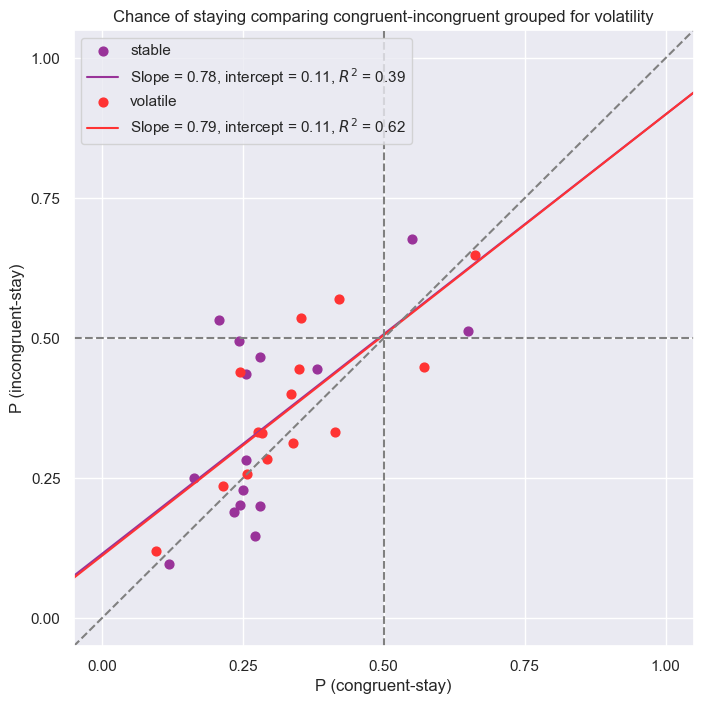

In [21]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(8, 8))
scatterplot_colours = ['#993399', '#FF3333']

for index, value in enumerate(unique_volatility_conditions):
    filtered_dataframe = CSIS_dataframe_averages.drop(CSIS_dataframe_averages[CSIS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_congruent_stay'], filtered_dataframe['p_incongruent_stay'], color=scatterplot_colours[index], label=value, s=40)

    # Extract x and y values
    x = filtered_dataframe['p_congruent_stay']
    y = filtered_dataframe['p_incongruent_stay']

    # Fit a regression line using numpy's polyfit (degree 1 for linear regression)
    slope, intercept = np.polyfit(x, y, 1)

    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0, 1]
    r_squared = correlation_xy**2

    # Plot the regression line
    ax.axline((0, intercept), slope=slope, color=scatterplot_colours[index], label=f'Slope = {slope:.2f}, intercept = {intercept:.2f}, $R^2$ = {r_squared:.2f}')

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (congruent-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (incongruent-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing congruent-incongruent grouped for {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(CSIS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [22]:
# First combine two columns
grouping_factor = 'valence'
dataframe_valence_volatility = dataframe_with_volatility

# Average the CSIS values for the staying condition
CSIS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 1) & (dataframe_valence_volatility.CSIS != 2)].index, inplace=False)
CSIS_dataframe_win_p['CSIS'] = CSIS_dataframe_win_p['CSIS'] - 1
CSIS_win_p_averages = CSIS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then do the same for the shifting condition
CSIS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 3) & (dataframe_valence_volatility.CSIS != 4)].index, inplace=False)
CSIS_dataframe_lose_p['CSIS'] = CSIS_dataframe_lose_p['CSIS'] - 3
CSIS_lose_p_averages = CSIS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then combine the two and rename the CSIS columns
CSIS_dataframe_averages = CSIS_win_p_averages[['subject_id', 'session', grouping_factor]]
CSIS_dataframe_averages['p_congruent_stay'] = CSIS_win_p_averages['CSIS']
CSIS_dataframe_averages['p_incongruent_stay'] = CSIS_lose_p_averages['CSIS']
print(CSIS_dataframe_averages)

   subject_id     session valence  p_congruent_stay  p_incongruent_stay
0     sub-801  session-01   angry          0.339744            0.293103
1     sub-801  session-01   happy          0.230769            0.212644
2     sub-802  session-01   angry          0.238636            0.480519
3     sub-802  session-01   happy          0.250000            0.461039
4     sub-803  session-01   angry          0.237805            0.222892
5     sub-803  session-01   happy          0.213415            0.198795
6     sub-804  session-01   angry          0.370370            0.505952
7     sub-804  session-01   happy          0.432099            0.500000
8     sub-805  session-01   angry          0.312500            0.415584
9     sub-805  session-01   happy          0.272727            0.428571
10    sub-806  session-01   angry          0.162651            0.268293
11    sub-806  session-01   happy          0.271084            0.304878
12    sub-807  session-01   angry          0.573171            0

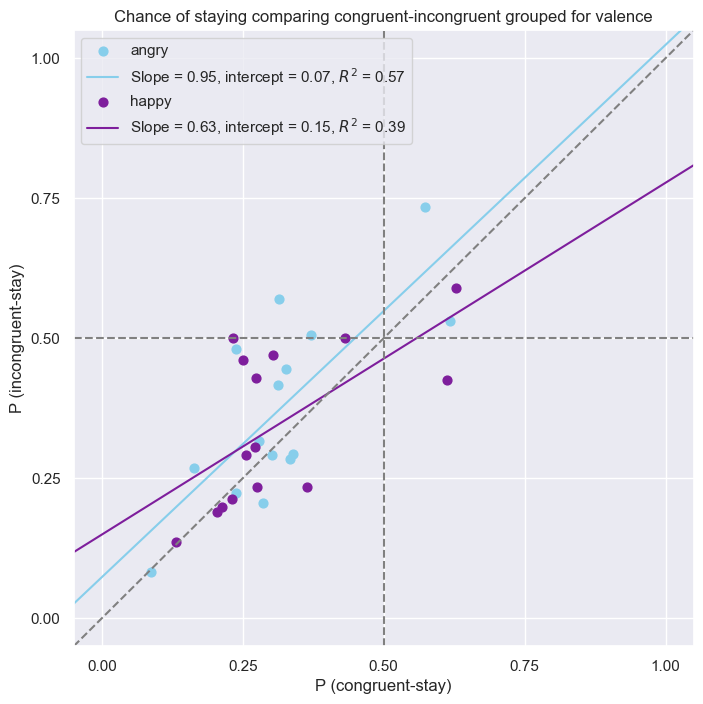

In [23]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(8 ,8))
scatterplot_colours = ['#87CEEB', '#7E1E9C']

for index, value in enumerate(unique_valence_conditions):
    filtered_dataframe = CSIS_dataframe_averages.drop(CSIS_dataframe_averages[CSIS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_congruent_stay'], filtered_dataframe['p_incongruent_stay'], color=scatterplot_colours[index], label=value, s=40)

    # Extract x and y values
    x = filtered_dataframe['p_congruent_stay']
    y = filtered_dataframe['p_incongruent_stay']

    # Fit a regression line using numpy's polyfit (degree 1 for linear regression)
    slope, intercept = np.polyfit(x, y, 1)

    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0, 1]
    r_squared = correlation_xy**2

    # Plot the regression line
    ax.axline((0, intercept), slope=slope, color=scatterplot_colours[index], label=f'Slope = {slope:.2f}, intercept = {intercept:.2f}, $R^2$ = {r_squared:.2f}')

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (congruent-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (incongruent-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing congruent-incongruent grouped for {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(CSIS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [24]:
# First combine two columns
grouping_factor_1 = 'valence'
grouping_factor_2 = 'volatility'
grouping_factor = f'{grouping_factor_1}_{grouping_factor_2}'
dataframe_valence_volatility = dataframe_with_volatility
dataframe_valence_volatility[grouping_factor] = dataframe_valence_volatility[grouping_factor_1] + ' & ' + dataframe_valence_volatility[grouping_factor_2]

# Average the CSIS values for the staying condition
CSIS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 1) & (dataframe_valence_volatility.CSIS != 2)].index, inplace=False)
CSIS_dataframe_win_p['CSIS'] = CSIS_dataframe_win_p['CSIS'] - 1
CSIS_win_p_averages = CSIS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then do the same for the shifting condition
CSIS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 3) & (dataframe_valence_volatility.CSIS != 4)].index, inplace=False)
CSIS_dataframe_lose_p['CSIS'] = CSIS_dataframe_lose_p['CSIS'] - 3
CSIS_lose_p_averages = CSIS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then combine the two and rename the CSIS columns
CSIS_dataframe_averages = CSIS_win_p_averages[['subject_id', 'session', grouping_factor]]
CSIS_dataframe_averages['p_congruent_stay'] = CSIS_win_p_averages['CSIS']
CSIS_dataframe_averages['p_incongruent_stay'] = CSIS_lose_p_averages['CSIS']
print(CSIS_dataframe_averages)

   subject_id     session valence_volatility  p_congruent_stay  \
0     sub-801  session-01     angry & stable          0.306818   
1     sub-801  session-01   angry & volatile          0.382353   
2     sub-801  session-01     happy & stable          0.181818   
3     sub-801  session-01   happy & volatile          0.294118   
4     sub-802  session-01     angry & stable          0.261905   
5     sub-802  session-01   angry & volatile          0.217391   
6     sub-802  session-01     happy & stable          0.226190   
7     sub-802  session-01   happy & volatile          0.271739   
8     sub-803  session-01     angry & stable          0.250000   
9     sub-803  session-01   angry & volatile          0.222222   
10    sub-803  session-01     happy & stable          0.217391   
11    sub-803  session-01   happy & volatile          0.208333   
12    sub-804  session-01     angry & stable          0.325000   
13    sub-804  session-01   angry & volatile          0.414634   
14    sub-

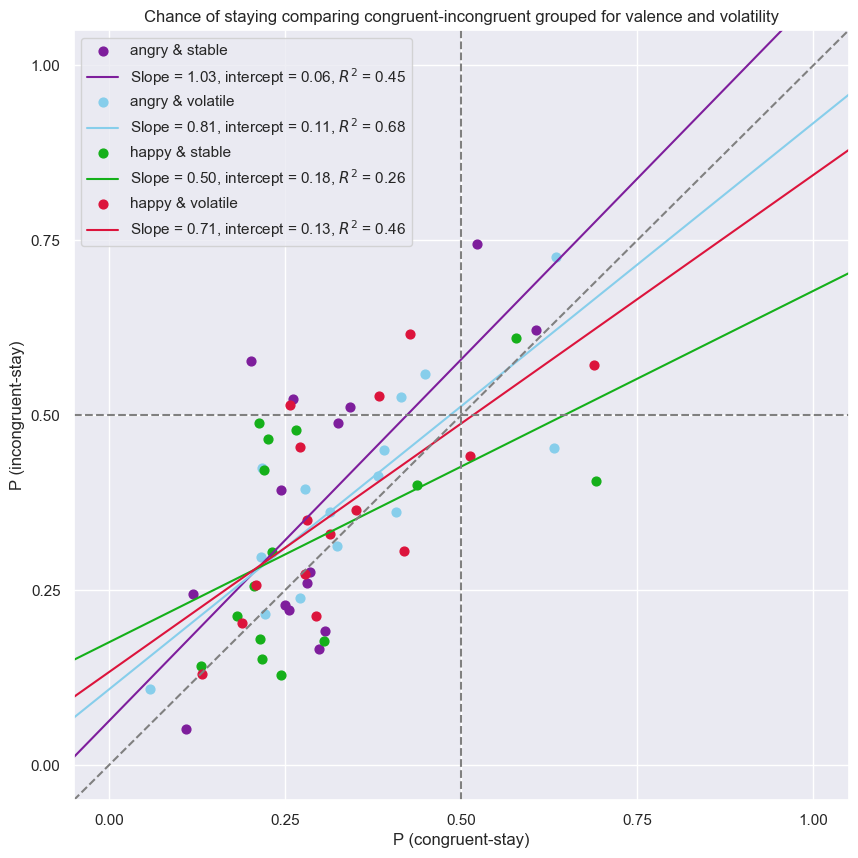

In [25]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(10, 10))
scatterplot_colours = ['#7E1E9C', '#87CEEB', '#15B01A', '#DC143C']
unique_conditions = CSIS_dataframe_averages['valence_volatility'].unique()

for index, value in enumerate(unique_conditions):
    filtered_dataframe = CSIS_dataframe_averages.drop(CSIS_dataframe_averages[CSIS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_congruent_stay'], filtered_dataframe['p_incongruent_stay'], color=scatterplot_colours[index], label=value, s=40)

    # Extract x and y values
    x = filtered_dataframe['p_congruent_stay']
    y = filtered_dataframe['p_incongruent_stay']

    # Fit a regression line using numpy's polyfit (degree 1 for linear regression)
    slope, intercept = np.polyfit(x, y, 1)

    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0, 1]
    r_squared = correlation_xy**2

    # Plot the regression line
    ax.axline((0, intercept), slope=slope, color=scatterplot_colours[index], label=f'Slope = {slope:.2f}, intercept = {intercept:.2f}, $R^2$ = {r_squared:.2f}')

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (congruent-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (incongruent-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing congruent-incongruent grouped for {grouping_factor_1} and {grouping_factor_2}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(CSIS_output_dir, f'{plot_name}.pdf'))
plt.show()